# Feature Engineering

## Import

In [1]:

from pyspark.ml import Pipeline, Estimator, Model
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.ml.feature import VectorAssembler,QuantileDiscretizer
#from synapse.ml.isolationforest import IsolationForest
from pyspark.sql.functions import first, sum, col, max, min, col, unix_timestamp, from_unixtime, lit, when, log1p, col, hour, dayofweek, to_timestamp, month
from pyspark.sql import functions as F
from pyspark.sql import SparkSession,Window
from pyspark.sql.types import IntegerType, DoubleType, StringType
import os
import seaborn as sns
import matplotlib.pyplot as plt
os.environ['HADOOP_HOME'] = "C:\\hadoop" 
# Добавляем путь к bin в системный PATH
os.environ['PATH'] += os.pathsep + "C:\\hadoop\\bin"

## ФУНКЦИЯ СБОРКИ ПАРКЕТА 

In [2]:
def finalize_parquet(folder_path, target_name):
    files = os.listdir(folder_path)
    # Добавляем [0] для получения строки
    part_file = [f for f in files if f.startswith("part-") and f.endswith(".parquet")][0]
    
    # Определяем путь к папке joined (на уровень выше временной папки)
    parent_dir = os.path.dirname(folder_path) 
    # Формируем полный путь: "../datasets/joined/train_data.parquet"
    final_path = os.path.join(parent_dir, target_name)
    
    # Если такой файл уже есть, os.rename может выдать ошибку, лучше удалить старый
    if os.path.exists(final_path):
        os.remove(final_path)

    os.rename(os.path.join(folder_path, part_file), final_path)
    
    # Очистка
    for f in os.listdir(folder_path):
        os.remove(os.path.join(folder_path, f))
    os.rmdir(folder_path)
    

In [3]:
train_files = ['../datasets/train/train_part_1.parquet','../datasets/train/train_part_2.parquet','../datasets/train/train_part_3.parquet']
train_path = '../datasets/train/'
# создание spark-сессии
spark =SparkSession.builder \
    .appName("feature_eng") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "1g") \
    .getOrCreate()
# загрузка исходных данных и списка релевантных для задачи признаков в объект DataFrame
df= spark.read.parquet(*train_files)

    # .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:1.1.2") \
    # .config("spark.jars.repositories", "https://mmlspark.azureedge.net/maven") \


In [4]:
df.columns

['customer_id',
 'event_id',
 'event_dttm',
 'event_type_nm',
 'event_desc',
 'channel_indicator_type',
 'channel_indicator_sub_type',
 'operaton_amt',
 'currency_iso_cd',
 'mcc_code',
 'pos_cd',
 'accept_language',
 'browser_language',
 'timezone',
 'session_id',
 'operating_system_type',
 'battery',
 'device_system_version',
 'screen_size',
 'developer_tools',
 'phone_voip_call_state',
 'web_rdp_connection',
 'compromised']

In [5]:
end_ts  = unix_timestamp(lit(df.select(F.max("event_dttm")).collect()[0][0]))
print(f"start_ts: {end_ts}")

start_ts: Column<'unix_timestamp('2025-05-31 23:59:59', 'yyyy-MM-dd HH:mm:ss')'>


In [6]:
start_ts  = unix_timestamp(lit(df.select(F.min("event_dttm")).collect()[0][0]))
print(f"end_ts: {start_ts}")

end_ts: Column<'unix_timestamp('2024-10-01 00:00:03', 'yyyy-MM-dd HH:mm:ss')'>


## CUT DATE PARAM

In [7]:
# 1. Задаем границы общего периода
period = None # 10%, NONE ЧТОБЫ ВЫКЛЮЧИТЬ
# Нижняя граница фильтра = Конец - 10% разницы
lower_bound_ts = end_ts - (end_ts - start_ts) * period

In [8]:
if period is not None:
    df = df.filter(
        col("event_dttm").between(
            from_unixtime(lower_bound_ts).cast("timestamp"), # приводим к timestamp
            from_unixtime(lit(end_ts)).cast("timestamp")     # тоже к timestamp
        )
    )

## Джойн лейблов + заполнение пропусков

In [9]:
df_labels = spark.read.parquet(r'../datasets/train/train_labels.parquet')
# df_labels = df_labels.withColumn("target", 
#     when(col("target") == 0, 1)
#     .otherwise(col("target"))
# )
df = df.join(other=df_labels,on=['customer_id', 'event_id'], how='left')

df = df.na.fill({
    "target": 0,
    # "label_category": "unknown"
})

important_labels = df_labels.event_id

## PREPROCESS AUF

### compromised

In [10]:
df = df.withColumn("compromised", 
    when(col("compromised").cast("byte") > 1, 1) # Привели -> Сравнили
    .otherwise(col("compromised").cast("byte"))   # Привели остальное
).fillna(-1, subset=["compromised"]) # НЕИЗВЕСТНОСТИ ЗАПОЛНИЛ  МИНУС ОДИН

### web_rdp_connection

In [11]:
df = df.fillna(-1, subset=["web_rdp_connection"]) \
       .withColumn("web_rdp_connection", col("web_rdp_connection").cast("byte"))

### phone_voip_call_state

In [12]:
df = df.fillna(-1, subset=["phone_voip_call_state"]) \
       .withColumn("phone_voip_call_state", col("phone_voip_call_state").cast("byte"))

### developer_tools

In [13]:
df = df.fillna(-1, subset=["developer_tools"]) \
       .withColumn("developer_tools", col("developer_tools").cast("byte"))

### screen_size

In [14]:
df = df.drop('screen_size') # УДАЛЕНО

### device_system_version

In [15]:
df = df.withColumn(
    'device_system_version', 
    F.regexp_extract(F.col('device_system_version'), r'(\d+)', 1).cast('int')
)
df = df.fillna(-1, subset=["device_system_version"]) \
       .withColumn("device_system_version", col("device_system_version").cast("byte"))


### battery

In [16]:
# df = df.drop('battery')

In [17]:
df = df.withColumn("battery", 
    when(col("battery") == 'not available', 0)    # Если 'not available' -> 0
    .when(col("battery").contains("%"), 1)        # Если есть процент -> 1
    .otherwise(col("battery").cast("byte"))       # В остальных случаях пытаемся в число
).fillna(-1, subset=["battery"])                  # Все пустые/невалидные -> -1

### operating_system_type

In [18]:
df = df.withColumn(
    'os_category',
    F.when(F.col('operating_system_type') == 6.0, 0)
     .when(F.col('operating_system_type') == 4.0, 1)
     .when(F.col('operating_system_type').isin([7.0, 9.0]), 2)
     .when(F.col('operating_system_type') == -1, -1) # Явно сохраняем -1
     .when(F.col('operating_system_type').isNull(), -1) # Обрабатываем null, если нужно
     .otherwise(3)
     .cast('byte')
).drop('operating_system_type')

### session_id

In [19]:
df = df.drop('session_id')

### timezone

In [20]:
df = df.withColumn(
    'tz_category',
    F.when(F.col('timezone') == -1, -1)                      # Сохраняем спецзначение
     .when(F.col('timezone') == 31, 0)                     # Условие для 0
     .when(F.col('timezone').isin([13, 21, 27, 16, 33, 20]), 1) # Группа 1
     .otherwise(2)                                           # Все остальные -> 2
     .cast('byte')                                           # Эквивалент int8
).drop('timezone')

### browser_language

In [21]:
df = df.withColumn("browser_language", 
    when(col("browser_language") == 'not available', 1) # 'not available' -> 1
    .otherwise(0)                                      # Всё остальное (любой текст или язык) -> 0
    .cast("byte")                                      # Гарантируем тип byte
)

### accept_language

In [22]:
df = df.withColumn(
    'language_category',
    F.when(F.col('accept_language').isNull(), -1)
     .when(F.lower(F.col('accept_language')) == 'ru', 0)
     .when(F.lower(F.col('accept_language')) == 'ru-ru', 1)
     # Проверяем наличие 'en' И 'ru' в строке (аналог 'en' in val and 'ru' in val)
     .when(F.lower(F.col('accept_language')).contains('en') & 
           F.lower(F.col('accept_language')).contains('ru'), 2)
     .otherwise(3)
     .cast('byte')
).drop('accept_language')

### mcc_code

In [23]:
# ПОКА ЧТО НЕТ ОБРАБОТКИ

### currency_iso_cd

In [24]:
df = df.withColumn("currency_iso_cd", 
    when(col("currency_iso_cd").cast("int") > 0, 1) # Сначала привели к числу, потом сравнили
    .otherwise(col("currency_iso_cd"))
    .cast("byte") # В самом конце гарантируем, что вся колонка — byte
).fillna(-1, subset=["currency_iso_cd"])

### operaton_amt

 СОЗДАЛ ПРИЗНАК КОТОРЫЙ ПРОПУСК В СУММЕ ОПЕРАЦИИ

In [25]:
# Если в 'other_col' пусто (NULL) -> True, иначе -> False
df = df.withColumn("operaton_amt_is_missing", 
    when(col("operaton_amt").isNull(), 1)
    .otherwise(0)
    .cast("byte")
)

ЗАПОЛНИЛ ПРОПУСКИ НУЛЯМИ

In [26]:
df = df.fillna(0, subset=["operaton_amt"])
# НЕИЗВЕСТНОСТИ ЗАПОЛНИЛ НУЛЯМИ

ПРОЛОГОРИФМИРОВАЛ СУММУ ОПЕРАЦИИ И ЗАПИСАЛ В НОВУЮ КОЛОНКУ

In [27]:
df = df.withColumn("operaton_amt_log", log1p(col("operaton_amt")))

### channel_indicator_sub_type

In [28]:
df = df.withColumn("channel_indicator_sub_type", col("channel_indicator_sub_type").cast("byte"))

### channel_indicator_type

In [29]:
df = df.withColumn("channel_indicator_type", col("channel_indicator_type").cast("byte"))

### event_dttm

In [30]:
df = df.withColumn("event_dttm", to_timestamp(col("event_dttm")))

# 2. Выделяем признаки (сразу в экономный тип byte)
df = df.withColumn("hour", hour(col("event_dttm")).cast("byte")) \
        .withColumn("month", month(col("event_dttm")).cast("byte"))\
       .withColumn("day_of_week", dayofweek(col("event_dttm")).cast("byte")) \
       .withColumn("is_night", 
           when((hour(col("event_dttm")) >= 0) & (hour(col("event_dttm")) < 6), 1)
           .otherwise(0)
           .cast("byte")
       )
df = df.drop('event_dttm')

## ЗАГРУЗКА TEST PARQUET

In [31]:
test_path = "../datasets/test/test.parquet"
pretest_path = "../datasets/test/pretest.parquet"
df_test = spark.read.parquet(test_path)
df_pretest = spark.read.parquet(pretest_path)

### test preproccess

In [32]:
### compromised
df_test = df_test.withColumn("compromised", 
    when(col("compromised").cast("byte") > 1, 1) # Привели -> Сравнили
    .otherwise(col("compromised").cast("byte"))   # Привели остальное
).fillna(-1, subset=["compromised"]) # НЕИЗВЕСТНОСТИ ЗАПОЛНИЛ  МИНУС ОДИН
### web_rdp_connection
df_test = df_test.fillna(-1, subset=["web_rdp_connection"]) \
       .withColumn("web_rdp_connection", col("web_rdp_connection").cast("byte"))
### phone_voip_call_state
df_test = df_test.fillna(-1, subset=["phone_voip_call_state"]) \
       .withColumn("phone_voip_call_state", col("phone_voip_call_state").cast("byte"))
### developer_tools
df_test = df_test.fillna(-1, subset=["developer_tools"]) \
       .withColumn("developer_tools", col("developer_tools").cast("byte"))
### screen_size
df_test = df_test.drop('screen_size') # УДАЛЕНО
### device_system_version
df_test = df_test.withColumn(
    'device_system_version', 
    F.regexp_extract(F.col('device_system_version'), r'(\d+)', 1).cast('int')
)
df_test = df_test.fillna(-1, subset=["device_system_version"]) \
       .withColumn("device_system_version", col("device_system_version").cast("byte"))

### battery
# df = df.drop('battery')
df_test = df_test.withColumn("battery", 
    when(col("battery") == 'not available', 0)    # Если 'not available' -> 0
    .when(col("battery").contains("%"), 1)        # Если есть процент -> 1
    .otherwise(col("battery").cast("byte"))       # В остальных случаях пытаемся в число
).fillna(-1, subset=["battery"])                  # Все пустые/невалидные -> -1
### operating_system_type
df_test = df_test.withColumn(
    'os_category',
    F.when(F.col('operating_system_type') == 6.0, 0)
     .when(F.col('operating_system_type') == 4.0, 1)
     .when(F.col('operating_system_type').isin([7.0, 9.0]), 2)
     .when(F.col('operating_system_type') == -1, -1) # Явно сохраняем -1
     .when(F.col('operating_system_type').isNull(), -1) # Обрабатываем null, если нужно
     .otherwise(3)
     .cast('byte')
).drop('operating_system_type')
### session_id
df_test = df_test.drop('session_id')
### timezone
df_test = df_test.withColumn(
    'tz_category',
    F.when(F.col('timezone') == -1, -1)                      # Сохраняем спецзначение
     .when(F.col('timezone') == 31, 0)                     # Условие для 0
     .when(F.col('timezone').isin([13, 21, 27, 16, 33, 20]), 1) # Группа 1
     .otherwise(2)                                           # Все остальные -> 2
     .cast('byte')                                           # Эквивалент int8
).drop('timezone')
### browser_language
df_test = df_test.withColumn("browser_language", 
    when(col("browser_language") == 'not available', 1) # 'not available' -> 1
    .otherwise(0)                                      # Всё остальное (любой текст или язык) -> 0
    .cast("byte")                                      # Гарантируем тип byte
)
### accept_language
df_test = df_test.withColumn(
    'language_category',
    F.when(F.col('accept_language').isNull(), -1)
     .when(F.lower(F.col('accept_language')) == 'ru', 0)
     .when(F.lower(F.col('accept_language')) == 'ru-ru', 1)
     # Проверяем наличие 'en' И 'ru' в строке (аналог 'en' in val and 'ru' in val)
     .when(F.lower(F.col('accept_language')).contains('en') & 
           F.lower(F.col('accept_language')).contains('ru'), 2)
     .otherwise(3)
     .cast('byte')
).drop('accept_language')
### mcc_code
# ПОКА ЧТО НЕТ ОБРАБОТКИ
### currency_iso_cd
df_test = df_test.withColumn("currency_iso_cd", 
    when(col("currency_iso_cd").cast("int") > 0, 1) # Сначала привели к числу, потом сравнили
    .otherwise(col("currency_iso_cd"))
    .cast("byte") # В самом конце гарантируем, что вся колонка — byte
).fillna(-1, subset=["currency_iso_cd"])
### operaton_amt
# СОЗДАЛ ПРИЗНАК КОТОРЫЙ ПРОПУСК В СУММЕ ОПЕРАЦИИ
# Если в 'other_col' пусто (NULL) -> True, иначе -> False
df_test = df_test.withColumn("operaton_amt_is_missing", 
    when(col("operaton_amt").isNull(), 1)
    .otherwise(0)
    .cast("byte")
)
#ЗАПОЛНИЛ ПРОПУСКИ НУЛЯМИ
df_test = df_test.fillna(0, subset=["operaton_amt"])
# НЕИЗВЕСТНОСТИ ЗАПОЛНИЛ НУЛЯМИ
#ПРОЛОГОРИФМИРОВАЛ СУММУ ОПЕРАЦИИ И ЗАПИСАЛ В НОВУЮ КОЛОНКУ
df_test = df_test.withColumn("operaton_amt_log", log1p(col("operaton_amt")))
### channel_indicator_sub_type
df_test = df_test.withColumn("channel_indicator_sub_type", col("channel_indicator_sub_type").cast("byte"))
### channel_indicator_type
df_test = df_test.withColumn("channel_indicator_type", col("channel_indicator_type").cast("byte"))
### event_dttm
df_test = df_test.withColumn("event_dttm", to_timestamp(col("event_dttm")))

# 2. Выделяем признаки (сразу в экономный тип byte)
df_test = df_test.withColumn("hour", hour(col("event_dttm")).cast("byte")) \
        .withColumn("month", month(col("event_dttm")).cast("byte")) \
       .withColumn("day_of_week", dayofweek(col("event_dttm")).cast("byte")) \
       .withColumn("is_night", 
           when((hour(col("event_dttm")) >= 0) & (hour(col("event_dttm")) < 6), 1)
           .otherwise(0)
           .cast("byte")
       )
df_test = df_test.drop('event_dttm')

## ЗАГРУЗКА PRETRAIN

In [33]:
pre_train_paths = ["../datasets/pretrain/pretrain_part_1.parquet", "../datasets/pretrain/pretrain_part_2.parquet", "../datasets/pretrain/pretrain_part_3.parquet"]
df_pretrain = spark.read.parquet(*pre_train_paths)

## PIPELINE БОГА 

In [34]:
# # 1. КЛАСС-МОДЕЛЬ: Просто приклеивает готовую таблицу агрегатов
# class UserHistoryModel(Model, DefaultParamsReadable, DefaultParamsWritable):
#     def __init__(self, user_profile):
#         super(UserHistoryModel, self).__init__()
#         self.user_profile = user_profile

#     def _transform(self, dataset):
#         # Джойним профили из истории к текущим событиям
#         enriched_df = dataset.join(self.user_profile, on="customer_id", how="left")
        
#         # Заполняем нулями тех, кого не было в истории
#         return enriched_df.fillna(0, subset=["hist_event_cnt", "hist_amt_sum"])

# # 2. КЛАСС-ОБУЧАТЕЛЬ: Вычисляет агрегаты по переданной истории
# class UserHistoryAggregator(Estimator, DefaultParamsReadable, DefaultParamsWritable):
#     def __init__(self, history_df):
#         super(UserHistoryAggregator, self).__init__()
#         self.history_df = history_df

#     def _fit(self, dataset):
#         # Здесь происходит тяжелая работа: расчет профиля по истории
#         user_profile = self.history_df.groupBy("customer_id").agg(
#             F.count("event_id").alias("hist_event_cnt"),
#             F.sum("operaton_amt").alias("hist_amt_sum"),
#             F.max("event_dttm").alias("hist_last_dt")
#         )
        
#         # Кэшируем результат, чтобы transform работал мгновенно
#         user_profile.cache()
        
#         return UserHistoryModel(user_profile=user_profile)

## ВКЛ И ВЫКЛ ПАЙПЛАЙНА

In [35]:
# # 1. Готовим "Базы знаний" (Историю)
# # Для трейна и валидации — только претрейн
# history_train = df_pretrain
# history_full = df_pretrain.unionByName(df_pretest).distinct()

# # --- ШАГ 1: ТРЕНИРОВКА (Валидация) ---
# # Создаем агрегатор, который видит только претрейн
# agg_train = UserHistoryAggregator(history_df=history_train)
# pipeline_train = Pipeline(stages=[agg_train])

# # Обучаем и применяем (Transform)
# model_train = pipeline_train.fit(df_train)
# df_train = model_train.transform(df_train)
# df_valid = model_train.transform(df_valid)

# # --- ШАГ 2: ТЕСТ (Продакшен-режим) ---
# # Создаем ТАКОЙ ЖЕ агрегатор, но с ОБНОВЛЕННОЙ историей
# agg_test = UserHistoryAggregator(history_df=history_full)
# pipeline_test = Pipeline(stages=[agg_test])

# # Обучаем заново (fit), чтобы зафиксировать новую таблицу агрегатов
# model_test = pipeline_test.fit(df_test)
# df_test = model_test.transform(df_test)

In [36]:
df.columns

['customer_id',
 'event_id',
 'event_type_nm',
 'event_desc',
 'channel_indicator_type',
 'channel_indicator_sub_type',
 'operaton_amt',
 'currency_iso_cd',
 'mcc_code',
 'pos_cd',
 'browser_language',
 'battery',
 'device_system_version',
 'developer_tools',
 'phone_voip_call_state',
 'web_rdp_connection',
 'compromised',
 'target',
 'os_category',
 'tz_category',
 'language_category',
 'operaton_amt_is_missing',
 'operaton_amt_log',
 'hour',
 'month',
 'day_of_week',
 'is_night']

## ЗАГЛУШКА КОТОРАЯ ВСЕ ПРОПУСКИ УБИРАЕТ!!!!!!!!

In [37]:
df = df.fillna(-1)
df_test = df_test.fillna(-1)

## ВЕЛИКОЕ ОЧИЩЕНИЕ 

In [38]:
# 2. Настройка: указываем логарифмированную колонку и категории
num_col = "operaton_amt_log" 
cat_cols =  [       
        "web_rdp_connection",
        "is_night",
        "os_category",
        'month',
        "event_desc",
        "hour",
        "event_type_nm",
        "pos_cd"
]




#СЮДА ПЕРЕДАВАТЬ ВАЖНОЕ, МАСТХЭВ, ТО ЧТО ОПРЕДЕЛЯЕТ СУЩНОСТЬ
output_bucket_col = "bucket_log"

In [39]:
# 3. Настройка дискретизатора
discretizer = QuantileDiscretizer(
    numBuckets=1000, 
    inputCol=num_col, 
    outputCol=output_bucket_col,
    relativeError=0.01 
)

In [40]:
# 4. Обучение и трансформация
# Spark просканирует данные, найдет границы квантилей и присвоит каждой строке ID бакета
df_prepared = discretizer.fit(df).transform(df)


In [41]:
# 5. Дедупликация
# Оставляем одну уникальную запись на комбинацию (бакет цены + ваши категории)
df_final = df_prepared.dropDuplicates([output_bucket_col] + cat_cols)

In [42]:
# 6. Очистка временных колонок
# Убираем bucket_log, чтобы оставить исходные 20 колонок
df_final = df_final.drop(output_bucket_col)

In [43]:
target_all = df.select('target').filter('target==1').count()
target_final = df_final.select('target').filter('target==1').count()
all_rows = df.count()
final_rows = df_final.count()

In [44]:
print('СТАТИСТИЧЕСКАЯ ВЫВОДКА')
print(f'Общее кол-во строк ALL: {all_rows}, фродов в ALL: {target_all}, частота появления фрода ALL {(target_all/all_rows)*100:.5f}%')
print(f'Общее кол-во строк FINAL: {final_rows}, фродов в FINAL: {target_final}, частота появления фрода FINAL {(target_final/final_rows)*100:.5f}%')
print(f'РАЗМЕРНОСТЬ СОКРАТИЛАСЬ ПО СТРОКАМ в {all_rows/final_rows:.3f} раз, ПО ФРОДУ В {target_all/target_final:.3f} раз')


СТАТИСТИЧЕСКАЯ ВЫВОДКА
Общее кол-во строк ALL: 85677840, фродов в ALL: 51438, частота появления фрода ALL 0.06004%
Общее кол-во строк FINAL: 2846799, фродов в FINAL: 2806, частота появления фрода FINAL 0.09857%
РАЗМЕРНОСТЬ СОКРАТИЛАСЬ ПО СТРОКАМ в 30.096 раз, ПО ФРОДУ В 18.331 раз


## ВОЗРАЩЕНИЕ ФРОДО

In [45]:
df_subset = df.filter(F.col('event_id').isin(important_labels))

df_final = df_final.union(df_subset).dropDuplicates()

## СРАВНЕНИЕ ИСХОДНОГО ПРЕПРОЦЕССНУТОГО И СВЕТЛОГО ФИЛЬТРОВАННОГО 

In [46]:
def plot_compare_distributions(df1, df2, columns, label1='FULL', label2='FILTER'):
    # 1. Берем выборку (sampling), чтобы не вешать драйвер, если данных миллионы
    # Если данных мало, можно просто .toPandas()
    p1 = df1.select(columns).sample(0.1).toPandas()
    p2 = df2.select(columns).toPandas()
    
    # 2. Настраиваем сетку графиков
    num_cols = len(columns)
    fig, axes = plt.subplots(nrows=(num_cols + 1) // 2, ncols=2, figsize=(15, num_cols * 2))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        # Рисуем плотность для обоих наборов на одном сабплоте
        sns.histplot(p1[col], ax=axes[i], label=label1, fill=True, alpha=0.3,kde=True,stat='density')
        sns.histplot(p2[col], ax=axes[i], label=label2, fill=True, alpha=0.3,kde=True,stat='density')
        
        axes[i].set_title(f'Distribution of {col}')
        axes[i].legend()

    plt.tight_layout()
    plt.show()

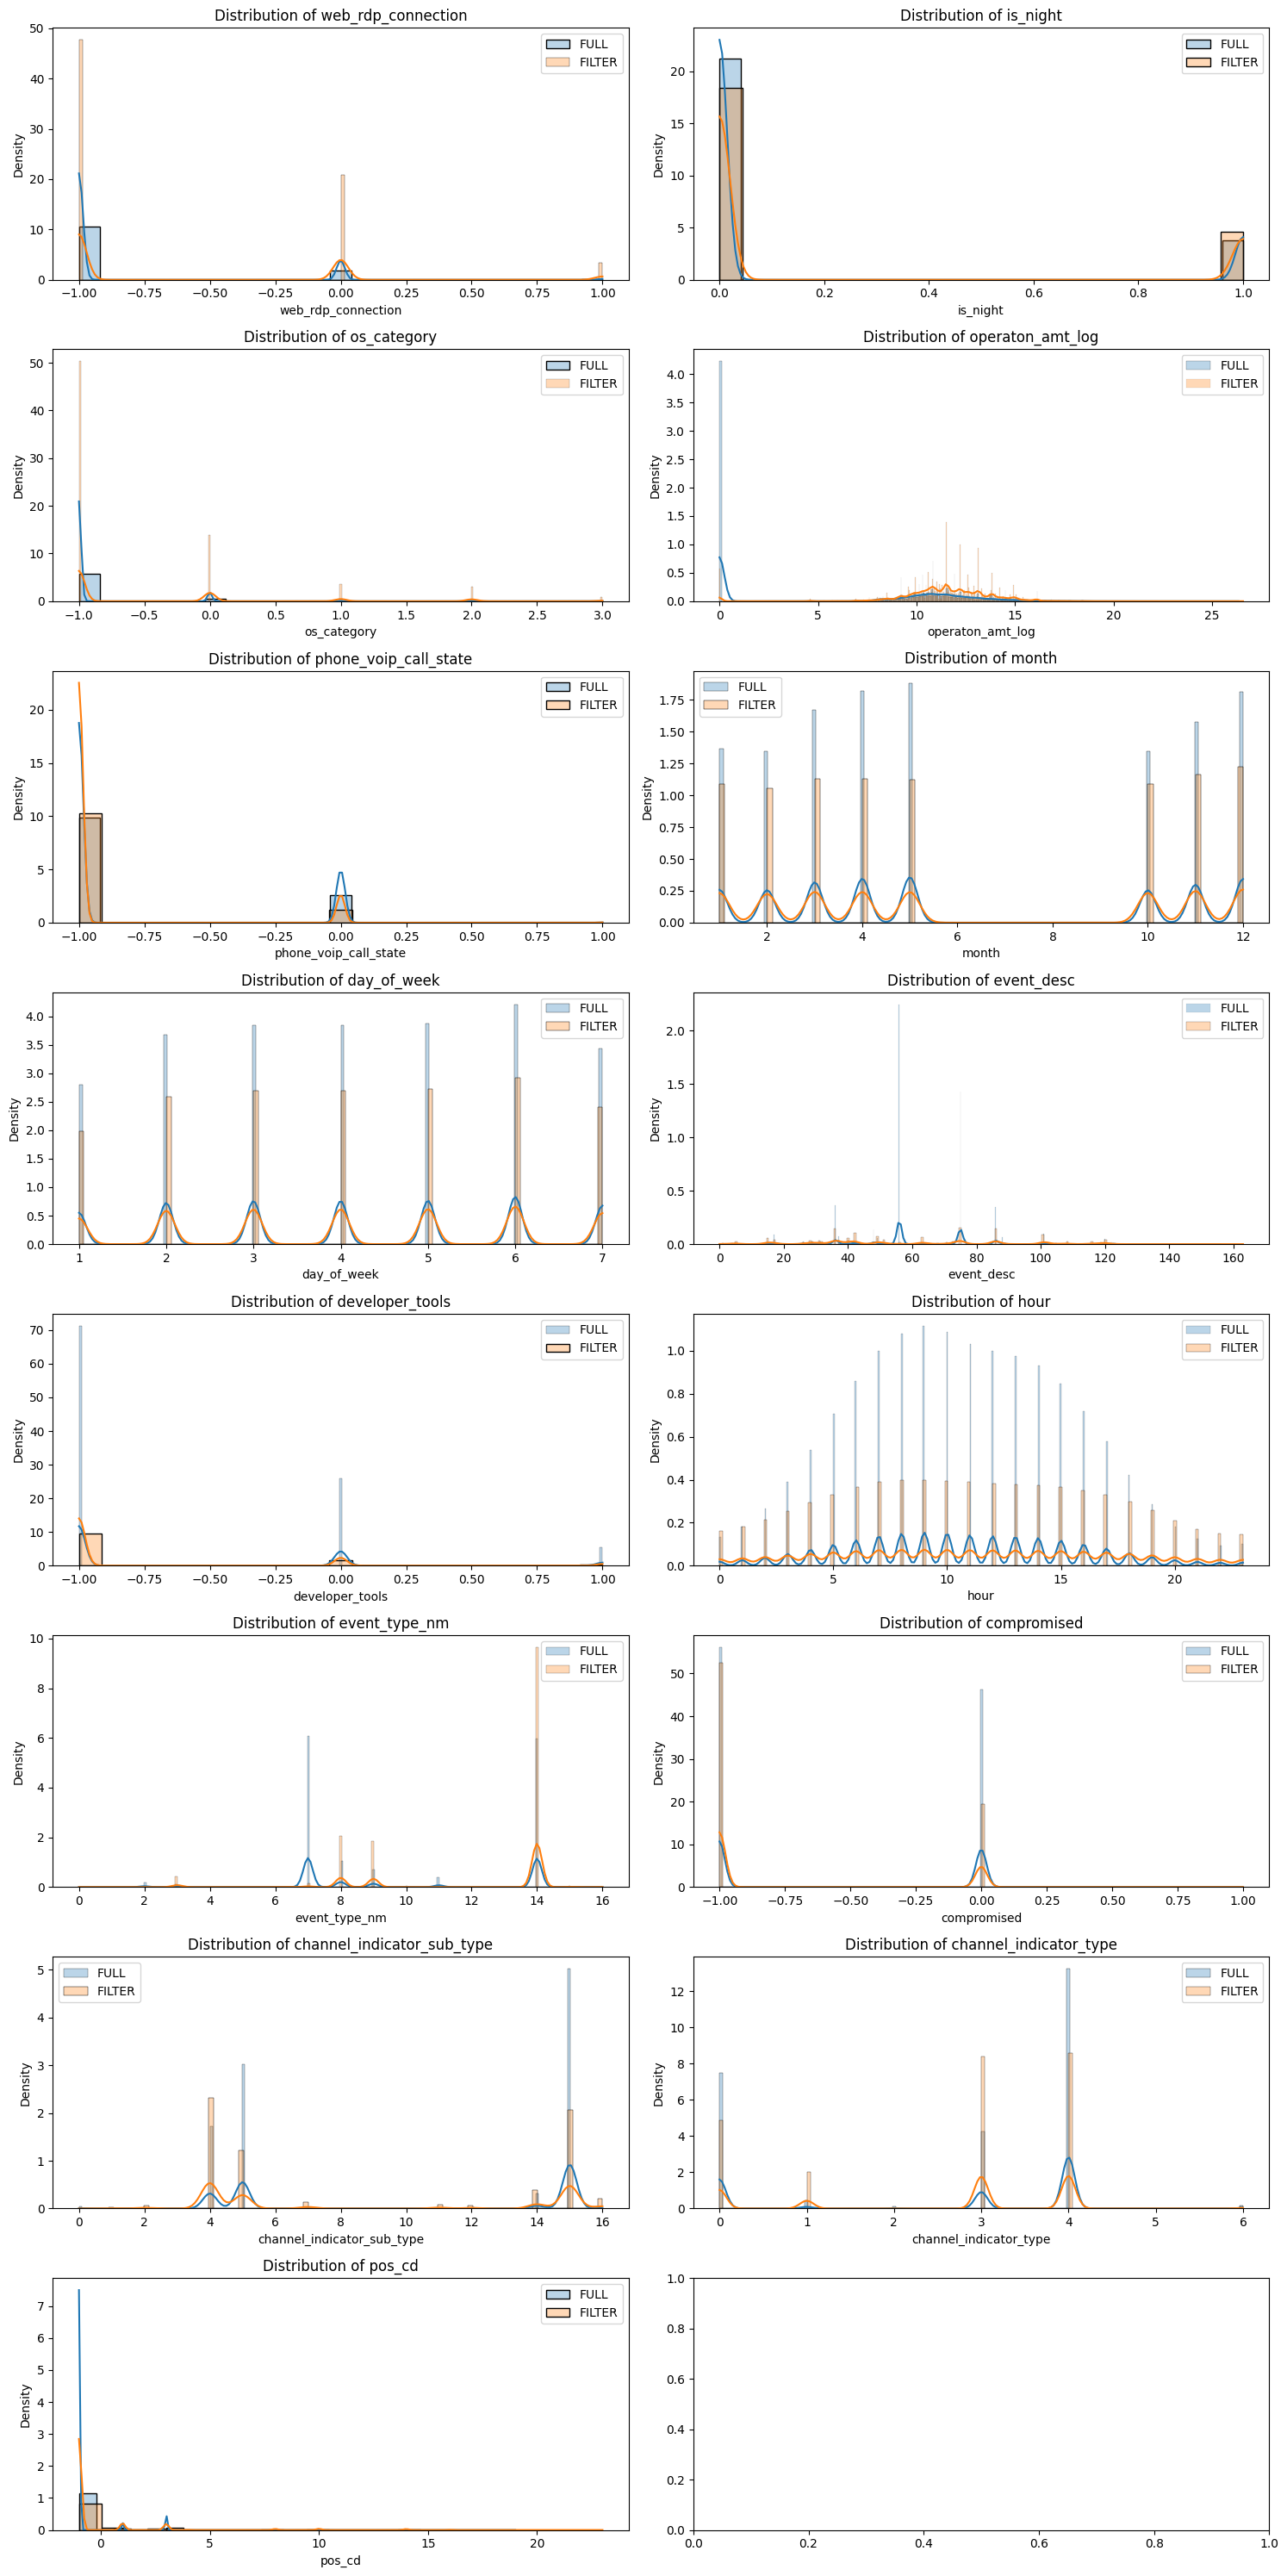

In [ ]:
# Использование:
cols_to_check = [       
        "web_rdp_connection",
        "is_night",
        "os_category",
        "operaton_amt_log",
        "phone_voip_call_state",
        # "customer_id",
        'month',
        "day_of_week",
        "event_desc",
        "developer_tools",
        "hour",
        "event_type_nm",
        "compromised",
        "channel_indicator_sub_type",
        "channel_indicator_type",
        # "tz_category",
        "pos_cd"
]
# plot_compare_distributions(df, df_final, cols_to_check)

## РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ВАЛИДАЦИОННУЮ 

In [48]:
fractions = {row[0]: 0.8 for row in df.select("target").distinct().collect()}

df_train = df_final.stat.sampleBy("target", fractions, seed=42)
df_valid = df_final.join(df_train, on="event_id", how="left_anti")


## ВЫГРУЗКА ФАЙЛОВ АЙОУ

In [49]:
# 2. Сохранение во временные папки с защитой от OOM (repartition)
train_temp = "../datasets/joined/temp_train_folder"
valid_temp = "../datasets/joined/temp_valid_folder"
test_temp = "../datasets/joined/temp_test_folder"

df_train.repartition(1).write.mode("overwrite").parquet(train_temp)
df_valid.repartition(1).write.mode("overwrite").parquet(valid_temp)
df_test.repartition(1).write.mode("overwrite").parquet(test_temp)

In [50]:
finalize_parquet(train_temp, "train_data.parquet")
finalize_parquet(valid_temp, "valid_data.parquet")
finalize_parquet(test_temp, "test_data.parquet")

print("Готово! Созданы файлы train_data.parquet, valid_data.parquet, test_data.parquet ")

Готово! Созданы файлы train_data.parquet, valid_data.parquet, test_data.parquet 


## ВЫХОДНОЙ СПИСОК КОЛОНОК 

In [51]:
df.columns

['customer_id',
 'event_id',
 'event_type_nm',
 'event_desc',
 'channel_indicator_type',
 'channel_indicator_sub_type',
 'operaton_amt',
 'currency_iso_cd',
 'mcc_code',
 'pos_cd',
 'browser_language',
 'battery',
 'device_system_version',
 'developer_tools',
 'phone_voip_call_state',
 'web_rdp_connection',
 'compromised',
 'target',
 'os_category',
 'tz_category',
 'language_category',
 'operaton_amt_is_missing',
 'operaton_amt_log',
 'hour',
 'month',
 'day_of_week',
 'is_night']

In [52]:
set_cols = set(df.columns)
set_cols = set_cols - set(['target','event_id'])
cat_cols = set_cols - set(['operaton_amt', 'operaton_amt_log'])
output_cols = {}
output_cols['all'] = list(set_cols)
output_cols['cat'] = list(cat_cols)
output_cols['target'] = 'target'
output_cols['id'] = 'event_id'

In [53]:
import json
with open('../datasets/joined/columns_list.json', "w", encoding="utf-8") as f:
    json.dump(output_cols, f, ensure_ascii=False, indent=4)

In [54]:
# with open('../datasets/joined/columns_list.txt',mode='w') as file_ik:
#     for i in range(len(df_train.columns)):
#         if i != len(df_train.columns)-1:
#             end = ','
#         else:
#             end = ''
#         file_ik.write(df_train.columns[i]+end)
